In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import average_precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score


In [2]:
import os

from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Colab Notebooks/Wind_Farm_A'
output_path = os.path.join(base_path, 'concatenated_output.csv')


Mounted at /content/drive


In [3]:
df = pd.read_csv(output_path)

In [4]:
df.head()

,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,sensor_1_avg,sensor_2_avg,wind_speed_3_avg,wind_speed_4_avg,...,sensor_48,sensor_49,sensor_50,sensor_51,sensor_52_avg,sensor_52_max,sensor_52_min,sensor_52_std,sensor_53_avg,source
0,2022-08-03 06:10:00,0,0,train,0,22.0,302.9,129.4,1.7,1.7,...,0.0,0.0,-1280.0,-496.0,0.0,0.0,0.0,0.0,26.0,0_csv
1,2022-08-03 06:20:00,0,1,train,0,22.0,307.1,133.6,1.7,1.7,...,0.0,0.0,-1278.0,-490.0,0.0,0.0,0.0,0.0,25.0,0_csv
2,2022-08-03 06:30:00,0,2,train,0,22.0,340.6,167.1,0.9,0.9,...,0.0,0.0,-1356.0,-490.0,0.0,0.0,0.0,0.0,25.0,0_csv
3,2022-08-03 06:40:00,0,3,train,0,22.0,124.4,-49.1,1.5,1.5,...,0.0,0.0,-1274.0,-509.0,0.0,0.0,0.0,0.0,26.0,0_csv
4,2022-08-03 06:50:00,0,4,train,0,22.0,66.2,-107.3,1.0,1.0,...,0.0,0.0,-1284.0,-499.0,0.0,0.0,0.0,0.0,26.0,0_csv


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1196747 entries, 0 to 1196746
Data columns (total 87 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   time_stamp             1196747 non-null  object 
 1   asset_id               1196747 non-null  int64  
 2   id                     1196747 non-null  int64  
 3   train_test             1196747 non-null  object 
 4   status_type_id         1196747 non-null  int64  
 5   sensor_0_avg           1196747 non-null  float64
 6   sensor_1_avg           1196747 non-null  float64
 7   sensor_2_avg           1196747 non-null  float64
 8   wind_speed_3_avg       1196747 non-null  float64
 9   wind_speed_4_avg       1196747 non-null  float64
 10  wind_speed_3_max       1196747 non-null  float64
 11  wind_speed_3_min       1196747 non-null  float64
 12  wind_speed_3_std       1196747 non-null  float64
 13  sensor_5_avg           1196747 non-null  float64
 14  sensor_5_max      

In [ ]:
unique_status_ids_prediction = df[df['train_test'] == 'prediction']['status_type_id'].unique()
for source in df['source'].unique():
    unique_status_ids = df[(df['train_test'] == 'prediction') & (df['source'] == source)]['status_type_id'].unique()
    print(f'Source: {source}, Unique Status IDs: {unique_status_ids}')

Source: 0_csv, Unique Status IDs: [0 5 3]
Source: 10_csv, Unique Status IDs: [0 3]
Source: 13_csv, Unique Status IDs: [0 5]
Source: 14_csv, Unique Status IDs: [0 5]
Source: 17_csv, Unique Status IDs: [0 5]
Source: 22_csv, Unique Status IDs: [0 3]
Source: 24_csv, Unique Status IDs: [0 5]
Source: 25_csv, Unique Status IDs: [0 5]
Source: 26_csv, Unique Status IDs: [0 3]
Source: 3_csv, Unique Status IDs: [5 0]
Source: 38_csv, Unique Status IDs: [0 5]
Source: 40_csv, Unique Status IDs: [0 5 3]
Source: 42_csv, Unique Status IDs: [0 3 5]
Source: 45_csv, Unique Status IDs: [4 3]
Source: 51_csv, Unique Status IDs: [0 3 5]
Source: 68_csv, Unique Status IDs: [0 3]
Source: 69_csv, Unique Status IDs: [0 5]
Source: 71_csv, Unique Status IDs: [0 5]
Source: 72_csv, Unique Status IDs: [0 3 5]
Source: 73_csv, Unique Status IDs: [0 3]
Source: 84_csv, Unique Status IDs: [4 3]
Source: 92_csv, Unique Status IDs: [0 5]


In [ ]:
unique_status_ids_train = df[df['train_test'] == 'train']['status_type_id'].unique()
for source in df['source'].unique():
    unique_status_ids = df[(df['train_test'] == 'train') & (df['source'] == source)]['status_type_id'].unique()
    print(f'Source: {source}, Unique Status IDs: {unique_status_ids}')

Source: 0_csv, Unique Status IDs: [0 5 3]
Source: 10_csv, Unique Status IDs: [0 3 5]
Source: 13_csv, Unique Status IDs: [5 0 3]
Source: 14_csv, Unique Status IDs: [4 3 0 5]
Source: 17_csv, Unique Status IDs: [0 5 3]
Source: 22_csv, Unique Status IDs: [0 5 3]
Source: 24_csv, Unique Status IDs: [0 3 5]
Source: 25_csv, Unique Status IDs: [5 0 3]
Source: 26_csv, Unique Status IDs: [0 5 3]
Source: 3_csv, Unique Status IDs: [0 5 3]
Source: 38_csv, Unique Status IDs: [0 5 4 3]
Source: 40_csv, Unique Status IDs: [0 5 3]
Source: 42_csv, Unique Status IDs: [0 5 3]
Source: 45_csv, Unique Status IDs: [0 5 4 3]
Source: 51_csv, Unique Status IDs: [3 0 5]
Source: 68_csv, Unique Status IDs: [5 0]
Source: 69_csv, Unique Status IDs: [0 5 3]
Source: 71_csv, Unique Status IDs: [0 5 3]
Source: 72_csv, Unique Status IDs: [5 0 3]
Source: 73_csv, Unique Status IDs: [0 5 3]
Source: 84_csv, Unique Status IDs: [0 5 4 3]
Source: 92_csv, Unique Status IDs: [5 0 3]


In [ ]:
df_0_csv = df[df['source'] == '0_csv']


In [ ]:
df_0_csv.head()

,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,sensor_1_avg,sensor_2_avg,wind_speed_3_avg,wind_speed_4_avg,...,sensor_48,sensor_49,sensor_50,sensor_51,sensor_52_avg,sensor_52_max,sensor_52_min,sensor_52_std,sensor_53_avg,source
0,2022-08-03 06:10:00,0,0,train,0,22.0,302.9,129.4,1.7,1.7,...,0.0,0.0,-1280.0,-496.0,0.0,0.0,0.0,0.0,26.0,0_csv
1,2022-08-03 06:20:00,0,1,train,0,22.0,307.1,133.6,1.7,1.7,...,0.0,0.0,-1278.0,-490.0,0.0,0.0,0.0,0.0,25.0,0_csv
2,2022-08-03 06:30:00,0,2,train,0,22.0,340.6,167.1,0.9,0.9,...,0.0,0.0,-1356.0,-490.0,0.0,0.0,0.0,0.0,25.0,0_csv
3,2022-08-03 06:40:00,0,3,train,0,22.0,124.4,-49.1,1.5,1.5,...,0.0,0.0,-1274.0,-509.0,0.0,0.0,0.0,0.0,26.0,0_csv
4,2022-08-03 06:50:00,0,4,train,0,22.0,66.2,-107.3,1.0,1.0,...,0.0,0.0,-1284.0,-499.0,0.0,0.0,0.0,0.0,26.0,0_csv


In [ ]:
df_0_csv['time_stamp'] = pd.to_datetime(df_0_csv['time_stamp'])

C:\Users\USER\AppData\Local\Temp\ipykernel_11356\773463666.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_0_csv['time_stamp'] = pd.to_datetime(df_0_csv['time_stamp'])


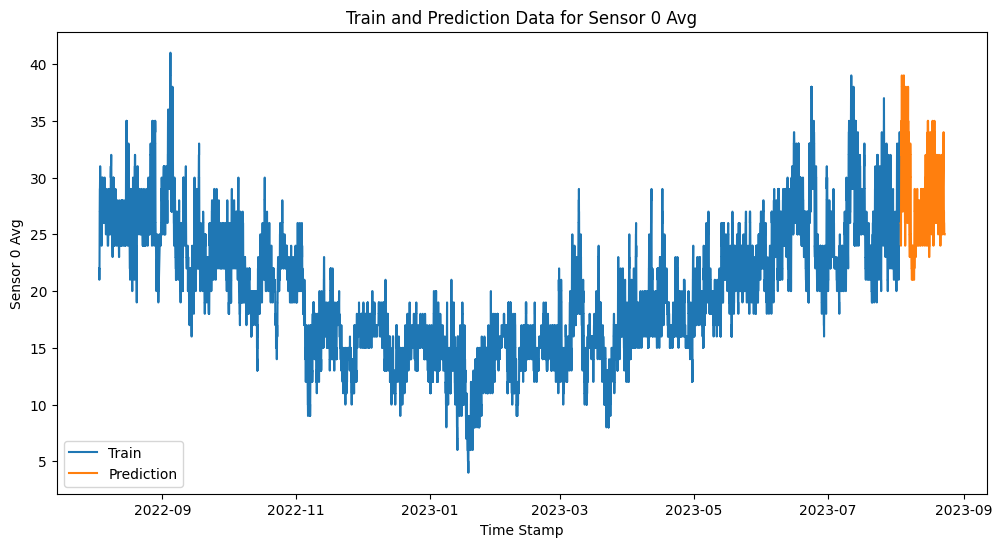

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_0_csv[df_0_csv['train_test'] == 'train']['time_stamp'], df_0_csv[df_0_csv['train_test'] == 'train']['sensor_0_avg'], label='Train')
plt.plot(df_0_csv[df_0_csv['train_test'] == 'prediction']['time_stamp'], df_0_csv[df_0_csv['train_test'] == 'prediction']['sensor_0_avg'], label='Prediction')
plt.xlabel('Time Stamp')
plt.ylabel('Sensor 0 Avg')
plt.title('Train and Prediction Data for Sensor 0 Avg')
plt.legend()
plt.show()

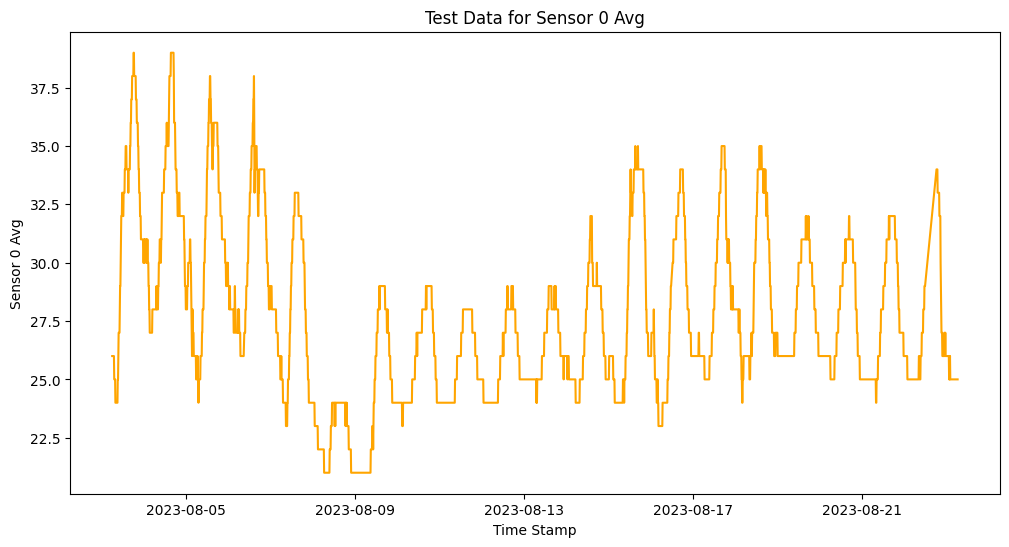

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_0_csv[df_0_csv['train_test'] == 'prediction']['time_stamp'], df_0_csv[df_0_csv['train_test'] == 'prediction']['sensor_0_avg'], label='Prediction', color='orange')
plt.xlabel('Time Stamp')
plt.ylabel('Sensor 0 Avg')
plt.title('Test Data for Sensor 0 Avg')
# plt.legend()
plt.show()

In [ ]:
unique_status_ids_train = df_0_csv[df_0_csv['train_test'] == 'train']['status_type_id'].unique()
print(unique_status_ids_train)

[0 5 3]


In [ ]:
df_0_csv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54986 entries, 0 to 54985
Data columns (total 87 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   time_stamp             54986 non-null  datetime64[ns]
 1   asset_id               54986 non-null  int64         
 2   id                     54986 non-null  int64         
 3   train_test             54986 non-null  object        
 4   status_type_id         54986 non-null  int64         
 5   sensor_0_avg           54986 non-null  float64       
 6   sensor_1_avg           54986 non-null  float64       
 7   sensor_2_avg           54986 non-null  float64       
 8   wind_speed_3_avg       54986 non-null  float64       
 9   wind_speed_4_avg       54986 non-null  float64       
 10  wind_speed_3_max       54986 non-null  float64       
 11  wind_speed_3_min       54986 non-null  float64       
 12  wind_speed_3_std       54986 non-null  float64       
 13  sensor

In [ ]:
col_2_drop = ['time_stamp','asset_id','id', 'train_test','status_type_id', 'source']

In [ ]:
# Step 1: Create X_train and X_test
X_train = df_0_csv[df_0_csv['train_test'] == 'train'].drop(columns=col_2_drop)
X_test = df_0_csv[df_0_csv['train_test'] == 'prediction'].drop(columns=col_2_drop)

# Step 2: Perform scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



NameError: name 'df_0_csv' is not defined

C:\Users\USER\AppData\Local\Temp\ipykernel_11356\3226248841.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_0_csv.loc[df_0_csv['train_test'] == 'prediction', 'anomaly_score'] = anomaly_scores
C:\Users\USER\AppData\Local\Temp\ipykernel_11356\3226248841.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_0_csv.loc[df_0_csv['train_test'] == 'prediction', 'anomaly'] = anomalies


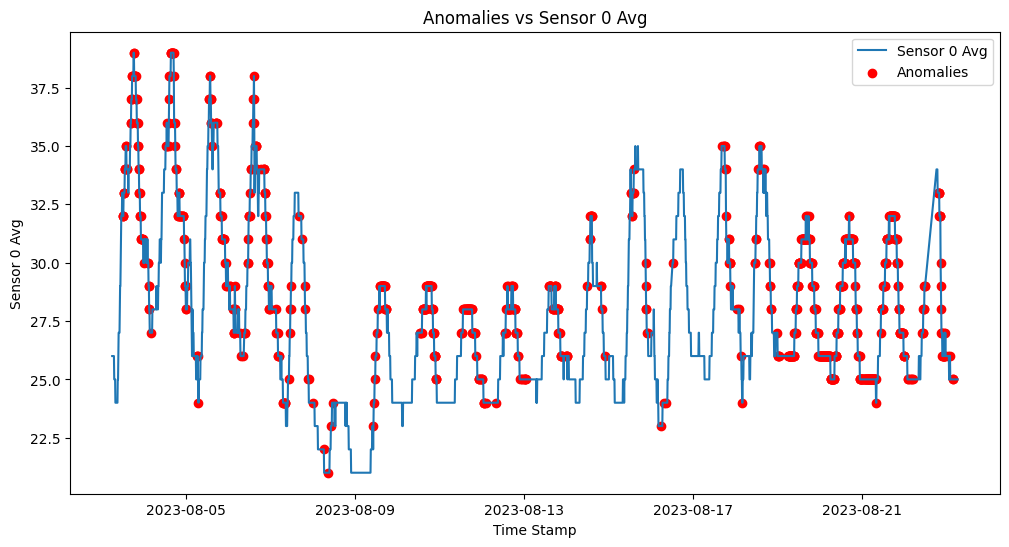

In [ ]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

# Step 3: Train IsolationForest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
iso_forest.fit(X_train_scaled)

# Step 4: Predict on X_test
anomaly_scores = iso_forest.decision_function(X_test_scaled)
anomalies = iso_forest.predict(X_test_scaled)

# Step 5: Create columns for anomaly score and anomaly identification
df_0_csv.loc[df_0_csv['train_test'] == 'prediction', 'anomaly_score'] = anomaly_scores
df_0_csv.loc[df_0_csv['train_test'] == 'prediction', 'anomaly'] = anomalies

# Step 6: Plot the anomalies vs the test data for sensor_0_avg
plt.figure(figsize=(12, 6))
plt.plot(df_0_csv[df_0_csv['train_test'] == 'prediction']['time_stamp'], df_0_csv[df_0_csv['train_test'] == 'prediction']['sensor_0_avg'], label='Sensor 0 Avg')
plt.scatter(df_0_csv[(df_0_csv['train_test'] == 'prediction') & (df_0_csv['anomaly'] == -1)]['time_stamp'], df_0_csv[(df_0_csv['train_test'] == 'prediction') & (df_0_csv['anomaly'] == -1)]['sensor_0_avg'], color='red', label='Anomalies')
plt.xlabel('Time Stamp')
plt.ylabel('Sensor 0 Avg')
plt.title('Anomalies vs Sensor 0 Avg')
plt.legend()
plt.show()

## Trying on full data



In [5]:
df_test = df[df['train_test'] == 'prediction']

df_test['status_type_id'].unique()

array([0, 5, 3, 4])

In [6]:
# Filter the training data with status type 0 and 2
# df_train = df[(df['train_test'] == 'train') & (df['status_type_id'].isin([0, 2]))]

# df_train = df[(df['train_test'] == 'train') & (df['status_type_id']==0)]

# Filter the test data with prediction label
# df_test = df[df['train_test'] == 'prediction']

df_train = df[(df['train_test'] == 'train') & (df['status_type_id'].isin([0,2]))]


df_train.head()
# print(df_test.head())

,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,sensor_1_avg,sensor_2_avg,wind_speed_3_avg,wind_speed_4_avg,...,sensor_48,sensor_49,sensor_50,sensor_51,sensor_52_avg,sensor_52_max,sensor_52_min,sensor_52_std,sensor_53_avg,source
0,2022-08-03 06:10:00,0,0,train,0,22.0,302.9,129.4,1.7,1.7,...,0.0,0.0,-1280.0,-496.0,0.0,0.0,0.0,0.0,26.0,0_csv
1,2022-08-03 06:20:00,0,1,train,0,22.0,307.1,133.6,1.7,1.7,...,0.0,0.0,-1278.0,-490.0,0.0,0.0,0.0,0.0,25.0,0_csv
2,2022-08-03 06:30:00,0,2,train,0,22.0,340.6,167.1,0.9,0.9,...,0.0,0.0,-1356.0,-490.0,0.0,0.0,0.0,0.0,25.0,0_csv
3,2022-08-03 06:40:00,0,3,train,0,22.0,124.4,-49.1,1.5,1.5,...,0.0,0.0,-1274.0,-509.0,0.0,0.0,0.0,0.0,26.0,0_csv
4,2022-08-03 06:50:00,0,4,train,0,22.0,66.2,-107.3,1.0,1.0,...,0.0,0.0,-1284.0,-499.0,0.0,0.0,0.0,0.0,26.0,0_csv


In [7]:
# Calculate total number of null values in df_train and df_test
total_null_train = df_train.isnull().sum().sum()
total_null_test = df_test.isnull().sum().sum()

print(f"Total null values in df_train: {total_null_train}")
print(f"Total null values in df_test: {total_null_test}")


Total null values in df_train: 10
Total null values in df_test: 8


In [8]:
# Drop rows with any null values in both training and testing datasets
df_train = df_train.dropna()
df_test = df_test.dropna()

# Recalculate total number of null values after dropping
total_null_train = df_train.isnull().sum().sum()
total_null_test = df_test.isnull().sum().sum()

print(f"Total null values in df_train after dropping: {total_null_train}")
print(f"Total null values in df_test after dropping: {total_null_test}")


Total null values in df_train after dropping: 0
Total null values in df_test after dropping: 0


In [9]:
def train_val_test_data(df_train, df_test, columns_to_drop, val_size=0.2, random_state=42):
    # Store feature column names for reference
    feature_columns = [col for col in df_train.columns if col not in columns_to_drop]

    # Extract features
    X_train_full = df_train.drop(columns=columns_to_drop)
    X_test = df_test.drop(columns=columns_to_drop)

    # Split training data into train and validation sets
    X_train, X_val = train_test_split(X_train_full, test_size=val_size, random_state=random_state)

    print(f"X_train shape: {X_train.shape}")
    print(f"X_val shape: {X_val.shape}")
    print(f"X_test shape: {X_test.shape}")

    return X_train, X_val, X_test, feature_columns


def scale(X_train, X_val, X_test, scaler_type='standard'):
    # Initialize scaler
    if scaler_type == 'standard':
        scaler = StandardScaler()
    elif scaler_type == 'minmax':
        scaler = MinMaxScaler()

    # Fit scaler on training data and transform all datasets
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_val_scaled, X_test_scaled, scaler


In [10]:
from sklearn.preprocessing import MinMaxScaler
# from sklearn.impute import SimpleImputer

columns_to_drop = ['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id', 'source']

X_train, X_val, X_test, feature_columns = train_val_test_data(df_train, df_test, columns_to_drop, val_size=0.2)

X_train_scaled, X_val_scaled, X_test_scaled, scaler = scale(X_train, X_val, X_test)

X_train shape: (687655, 81)
X_val shape: (171914, 81)
X_test shape: (50589, 81)


In [11]:
from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt

# Train IsolationForest
iso_forest = IsolationForest(contamination=0.5, random_state=42)
iso_forest.fit(X_train_scaled)

# Predict on X_test_scaled_imputed
anomaly_scores = iso_forest.decision_function(X_test_scaled)
anomalies = iso_forest.predict(X_test_scaled)

# Create columns for anomaly score and anomaly identification
df_test['iso_anomaly_score'] = anomaly_scores
df_test['iso_anomaly'] = anomalies



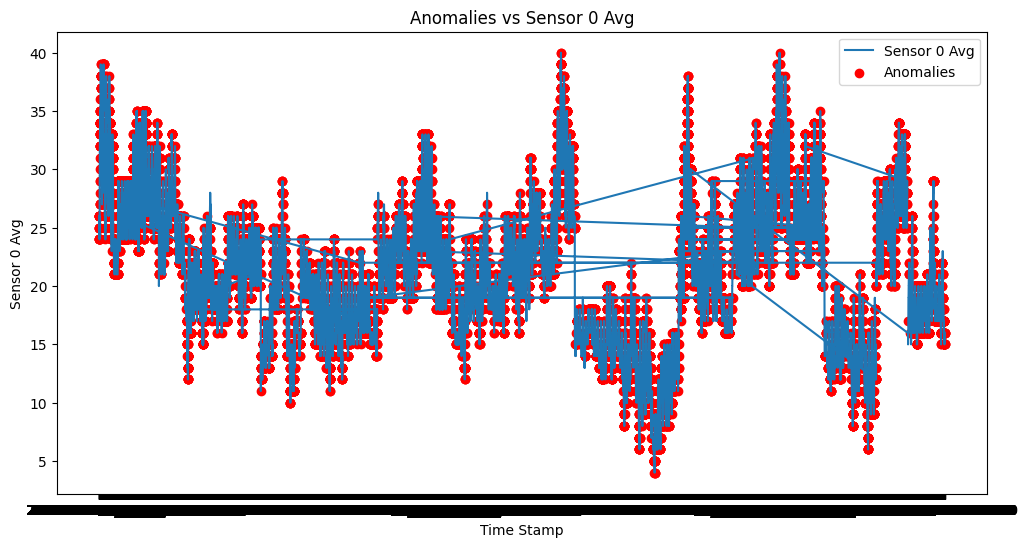

Precision: 0.05279187817258883
Recall: 0.5712193335774441
F1 Score: 0.0966512809392522


In [ ]:
# Plot the anomalies vs the test data for sensor_0_avg
plt.figure(figsize=(12, 6))
plt.plot(df_test['time_stamp'], df_test['sensor_0_avg'], label='Sensor 0 Avg')
plt.scatter(df_test[df_test['iso_anomaly'] == -1]['time_stamp'], df_test[df_test['iso_anomaly'] == -1]['sensor_0_avg'], color='red', label='Anomalies')
plt.xlabel('Time Stamp')
plt.ylabel('Sensor 0 Avg')
plt.title('Anomalies vs Sensor 0 Avg')
plt.legend()
plt.show()

# Evaluate the anomalies
true_anomalies = df_test[df_test['status_type_id'] == 4]
predicted_anomalies = df_test[df_test['iso_anomaly'] == -1]

# Calculate the score
true_positive = len(predicted_anomalies[predicted_anomalies['status_type_id'] == 4])
false_positive = len(predicted_anomalies[predicted_anomalies['status_type_id'] != 4])
false_negative = len(true_anomalies[true_anomalies['iso_anomaly'] != -1])
true_negative = len(df_test) - true_positive - false_positive - false_negative

precision = true_positive / (true_positive + false_positive)
recall = true_positive / (true_positive + false_negative)
f1 = 2 * (precision * recall) / (precision + recall)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

  ### AE Implementation

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

# Define the Autoencoder model
input_dim = X_train_scaled.shape[1]
encoding_dim = 44

input_layer = Input(shape=(input_dim,))
encoded = GaussianNoise(0.1)(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)
encoded = Dense(25, activation='relu')(encoded)
encoded = Dense(4, activation='relu')(encoded)
decoded = Dense(25, activation='relu')(encoded)
decoded = Dense(encoding_dim, activation='relu')(decoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.0018), loss='mse')



Epoch 1/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - loss: 0.6496 - val_loss: 0.6147
Epoch 2/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - loss: 0.6162 - val_loss: 0.6108
Epoch 3/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 0.6227 - val_loss: 0.6110
Epoch 4/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 0.6145 - val_loss: 0.6071
Epoch 5/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - loss: 0.6330 - val_loss: 0.6060
Epoch 6/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 0.6243 - val_loss: 0.6029
Epoch 7/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - loss: 0.6034 - val_loss: 0.6020
Epoch 8/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - loss: 0.6218 - val_loss: 0.6000
Epoch 9/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 0.6067 - val_loss: 0.5998
Epoch 10/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 0.6036 - val_loss: 0.5996
Epoch 11/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - loss: 0.6005 - val

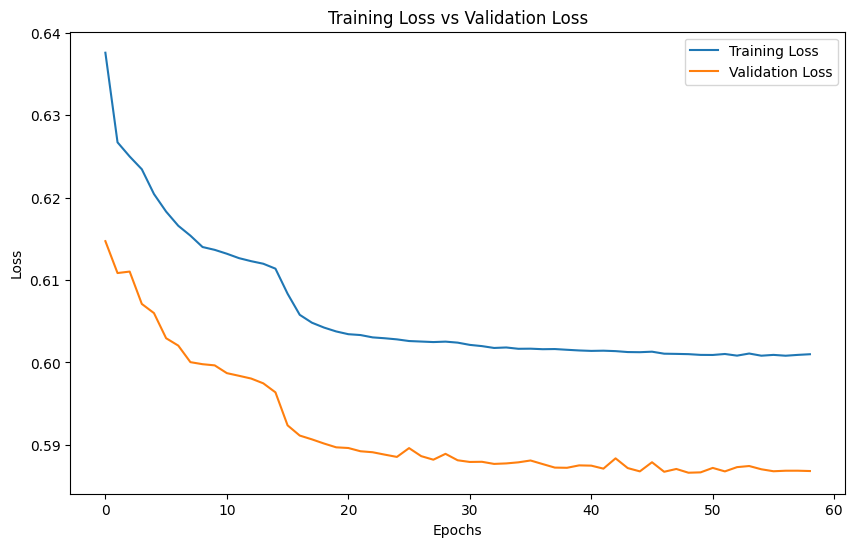

In [ ]:
# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the Autoencoder
history = autoencoder.fit(X_train_scaled, X_train_scaled,
                          epochs=100,
                          batch_size=64,
                          shuffle=True,
                          validation_data=(X_val_scaled, X_val_scaled),
                          callbacks=[early_stopping])

# Plot the training loss vs validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
autoencoder.save('autoencoder_model.keras')

In [12]:
from tensorflow.keras.models import load_model

# Load the autoencoder model
autoencoder = load_model('autoencoder_model.keras')

In [13]:
X_train_reconstructed = autoencoder.predict(X_train_scaled)
train_reconstruction_error = np.mean(np.square(X_train_scaled - X_train_reconstructed), axis=1)

# Calculate reconstruction error for test data
X_val_reconstructed = autoencoder.predict(X_val_scaled)
val_reconstruction_error = np.mean(np.square(X_val_scaled - X_val_reconstructed), axis=1)



21490/21490 ━━━━━━━━━━━━━━━━━━━━ 33s 1ms/step
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 8.1 MB/s eta 0:00:00


In [ ]:
# import optuna
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
# from sklearn.metrics import mean_squared_error
# import numpy as np

# # Define the objective function for Optuna
# def objective(trial):
#     # Suggest hyperparameters
#     n_units1 = trial.suggest_int('n_units1', 16, 128)
#     n_units2 = trial.suggest_int('n_units2', 16, 128)
#     learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-1)
#     gamma = trial.suggest_uniform('gamma', 0.2, 0.4)

#     # Define the NN model
#     model = Sequential()
#     model.add(Dense(n_units1, input_dim=X_train_scaled.shape[1], activation='relu'))
#     model.add(Dense(n_units2, activation='relu'))
#     model.add(Dense(1, activation='linear'))

#     # Compile the model
#     model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')

#     # Early stopping callback
#     early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

#     # Train the model
#     history = model.fit(X_train_scaled, train_reconstruction_error,
#                         epochs=100,
#                         batch_size=64,
#                         shuffle=True,
#                         validation_data=(X_val_scaled, val_reconstruction_error),
#                         callbacks=[early_stopping],
#                         verbose=0)

#     # Evaluate the model
#     val_predictions = model.predict(X_val_scaled)
#     val_loss = mean_squared_error(val_reconstruction_error, val_predictions)

#     return val_loss



In [ ]:
# Create a study object and optimize the objective function
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# Get the best hyperparameters
best_params = study.best_params
print(f'Best hyperparameters: {best_params}')

# Train the final model with the best hyperparameters
best_model = Sequential()
best_model.add(Dense(best_params['n_units1'], input_dim=X_train_scaled.shape[1], activation='relu'))
best_model.add(Dense(best_params['n_units2'], activation='relu'))
best_model.add(Dense(1, activation='linear'))

best_model.compile(optimizer=Adam(learning_rate=best_params['learning_rate']), loss='mse')

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = best_model.fit(X_train_scaled, train_reconstruction_error,
                         epochs=100,
                         batch_size=64,
                         shuffle=True,
                         validation_data=(X_val_scaled, val_reconstruction_error),
                         callbacks=[early_stopping])

# Plot the training loss vs validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()
plt.show()

[I 2025-03-12 23:45:50,520] A new study created in memory with name: no-name-ae51d9ad-6a4d-4186-ae2a-7e30138daffc
C:\Users\USER\AppData\Local\Temp\ipykernel_11960\109560831.py:14: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-1)
C:\Users\USER\AppData\Local\Temp\ipykernel_11960\109560831.py:15: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  gamma = trial.suggest_uniform('gamma', 0.2, 0.4)
c:\Users\USER\Desktop\DATA SCIENCE\Predictive_Maintenance_IFP_Project\venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer

5373/5373 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


[I 2025-03-13 00:03:20,081] Trial 0 finished with value: 595.4171092477092 and parameters: {'n_units1': 106, 'n_units2': 120, 'learning_rate': 7.086386379903484e-05, 'gamma': 0.20904866786793036}. Best is trial 0 with value: 595.4171092477092.
C:\Users\USER\AppData\Local\Temp\ipykernel_11960\109560831.py:14: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-1)
C:\Users\USER\AppData\Local\Temp\ipykernel_11960\109560831.py:15: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  gamma = trial.suggest_uniform('gamma', 0.2, 0.4)
c:\Users\USER\Desktop\DATA SCIENCE\Predictive_Maintenance_IFP_Project\venv\Lib\site-packages\keras\src\layers

5373/5373 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


[I 2025-03-13 00:08:00,506] Trial 1 finished with value: 799.2255757658985 and parameters: {'n_units1': 62, 'n_units2': 124, 'learning_rate': 0.037270946153246956, 'gamma': 0.2499363904742016}. Best is trial 0 with value: 595.4171092477092.
C:\Users\USER\AppData\Local\Temp\ipykernel_11960\109560831.py:14: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-1)
C:\Users\USER\AppData\Local\Temp\ipykernel_11960\109560831.py:15: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  gamma = trial.suggest_uniform('gamma', 0.2, 0.4)
c:\Users\USER\Desktop\DATA SCIENCE\Predictive_Maintenance_IFP_Project\venv\Lib\site-packages\keras\src\layers\co

...

[I 2025-03-13 06:10:01,031] Trial 20 finished with value: 793.3519729298582 and parameters: {'n_units1': 30, 'n_units2': 81, 'learning_rate': 0.024248400534649606, 'gamma': 0.33789364145510226}. Best is trial 17 with value: 0.6853708195452531.
C:\Users\USER\AppData\Local\Temp\ipykernel_11960\109560831.py:14: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-1)
C:\Users\USER\AppData\Local\Temp\ipykernel_11960\109560831.py:15: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  gamma = trial.suggest_uniform('gamma', 0.2, 0.4)
c:\Users\USER\Desktop\DATA SCIENCE\Predictive_Maintenance_IFP_Project\venv\Lib\site-packages\keras\src\layers

5373/5373 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


[I 2025-03-13 06:14:36,819] Trial 21 finished with value: 73.06330698827078 and parameters: {'n_units1': 54, 'n_units2': 68, 'learning_rate': 0.009220959272514786, 'gamma': 0.2847897587939508}. Best is trial 17 with value: 0.6853708195452531.
C:\Users\USER\AppData\Local\Temp\ipykernel_11960\109560831.py:14: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-1)
C:\Users\USER\AppData\Local\Temp\ipykernel_11960\109560831.py:15: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  gamma = trial.suggest_uniform('gamma', 0.2, 0.4)
c:\Users\USER\Desktop\DATA SCIENCE\Predictive_Maintenance_IFP_Project\venv\Lib\site-packages\keras\src\layers\

5373/5373 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


[I 2025-03-13 06:18:31,612] Trial 22 finished with value: 459.7294848440042 and parameters: {'n_units1': 69, 'n_units2': 59, 'learning_rate': 0.004051010151376523, 'gamma': 0.26639321633183555}. Best is trial 17 with value: 0.6853708195452531.
C:\Users\USER\AppData\Local\Temp\ipykernel_11960\109560831.py:14: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-1)
C:\Users\USER\AppData\Local\Temp\ipykernel_11960\109560831.py:15: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  gamma = trial.suggest_uniform('gamma', 0.2, 0.4)
c:\Users\USER\Desktop\DATA SCIENCE\Predictive_Maintenance_IFP_Project\venv\Lib\site-packages\keras\src\layers

In [ ]:
# {'n_units1': 114, 'n_units2': 127, 'learning_rate': 0.0014457801407514394, 'gamma': 0.31909487652844054}
# {'n_units1': 101, 'n_units2': 42, 'learning_rate': 0.017970575010749418, 'gamma': 0.39586403837356254}. Best is trial 7 with value: 47.12560499504745.
# 5.803869230577486 and parameters: {'n_units1': 58, 'n_units2': 63, 'learning_rate': 0.0058880765667593295, 'gamma': 0.3996394062414927}
# 0.6853708195452531 and parameters: {'n_units1': 62, 'n_units2': 97, 'learning_rate': 0.005596230497244941, 'gamma': 0.2869858485567594}

In [ ]:
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import numpy as np

import matplotlib.pyplot as plt

# Best hyperparameters
best_params = {'n_units1': 62, 'n_units2': 97, 'learning_rate': 0.005596230497244941, 'gamma': 0.2869858485567594}

# # Define the ANN model
# model = Sequential()
# model.add(Dense(best_params['n_units1'], input_dim=X_train_scaled.shape[1], activation='relu'))
# model.add(Dense(best_params['n_units2'], activation='relu'))
# model.add(Dense(1, activation='linear'))

model = Sequential()
model.add(Dense(best_params['n_units1'], input_dim=X_train_scaled.shape[1], activation='relu',
                kernel_regularizer=regularizers.l2(0.01)))  # L2 regularization
model.add(Dense(best_params['n_units2'], activation='relu',
                kernel_regularizer=regularizers.l1(0.001)))  # L1 regularization
model.add(Dense(1, activation='linear'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=best_params['learning_rate']), loss='mse')

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train_scaled, train_reconstruction_error,
                    epochs=100,
                    batch_size=64,
                    shuffle=True,
                    validation_data=(X_val_scaled, val_reconstruction_error),
                    callbacks=[early_stopping])

# Plot the training loss vs validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()
plt.show()

# Calculate mean and RMSE for training and validation data
train_predictions = model.predict(X_train_scaled)
val_predictions = model.predict(X_val_scaled)

train_mean = np.mean(train_predictions)
val_mean = np.mean(val_predictions)

train_rmse = np.sqrt(mean_squared_error(train_reconstruction_error, train_predictions))
val_rmse = np.sqrt(mean_squared_error(val_reconstruction_error, val_predictions))

print(f'Training Mean: {train_mean}')
print(f'Validation Mean: {val_mean}')
print(f'Training RMSE: {train_rmse}')
print(f'Validation RMSE: {val_rmse}')

In [ ]:
model.save('ann_model.keras')

In [14]:
ann_model = load_model('ann_model.keras')

Epoch 1/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 2.2172 - val_loss: 322.4463
Epoch 2/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 3.1576 - val_loss: 587.3235
Epoch 3/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - loss: 0.9528 - val_loss: 801.5026
Epoch 4/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - loss: 6.1892 - val_loss: 798.4717
Epoch 5/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - loss: 14.4833 - val_loss: 624.4620
Epoch 6/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 2.3857 - val_loss: 636.8552
Epoch 7/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - loss: 5.0730 - val_loss: 798.1536
Epoch 8/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - loss: 4.2694 - val_loss: 798.0856
Epoch 9/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - loss: 2.5431 - val_loss: 798.0331
Epoch 10/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 8.6884 - val_loss: 797.9943
Epoch 11/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step

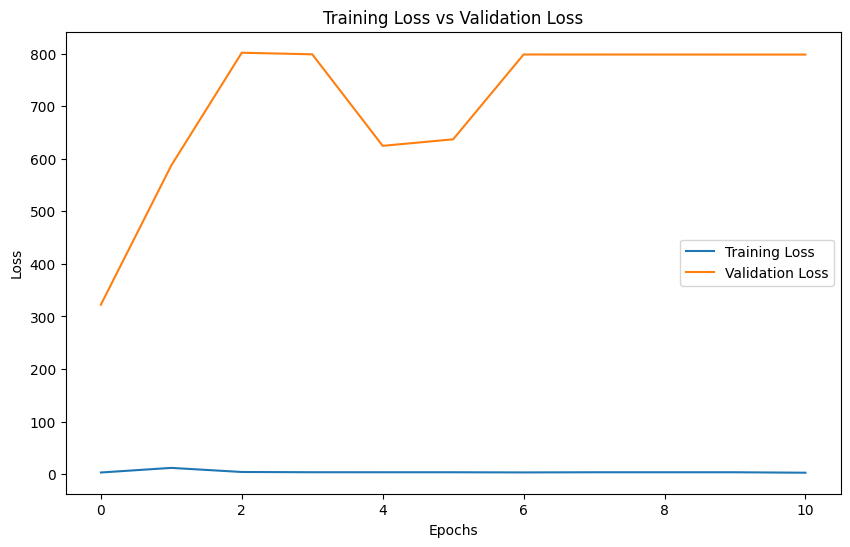

21490/21490 ━━━━━━━━━━━━━━━━━━━━ 30s 1ms/step
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
Training Mean: 0.5621219873428345
Validation Mean: 0.5865896344184875
Training RMSE: 1.2297592525151035
Validation RMSE: 17.956842569735937


In [ ]:
# # Best hyperparameters
# # best_params = {'n_units1': 101, 'n_units2': 42, 'learning_rate': 0.017970575010749418, 'gamma': 0.39586403837356254}
# best_params = {'n_units1': 58, 'n_units2': 63, 'learning_rate': 0.006, 'gamma': 0.3}

# # Define the ANN model
# model = Sequential()
# model.add(Dense(best_params['n_units1'], input_dim=X_train_scaled.shape[1], activation='relu'))
# model.add(Dense(best_params['n_units2'], activation='relu'))
# model.add(Dense(1, activation='linear'))

# # Compile the model
# model.compile(optimizer=Adam(learning_rate=best_params['learning_rate']), loss='mse')

# # Early stopping callback
# early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# # Train the model
# history = model.fit(X_train_scaled, train_reconstruction_error,
#                     epochs=100,
#                     batch_size=64,
#                     shuffle=True,
#                     validation_data=(X_val_scaled, val_reconstruction_error),
#                     callbacks=[early_stopping])

# # Plot the training loss vs validation loss
# plt.figure(figsize=(10, 6))
# plt.plot(history.history['loss'], label='Training Loss')
# plt.plot(history.history['val_loss'], label='Validation Loss')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.title('Training Loss vs Validation Loss')
# plt.legend()
# plt.show()

# # Calculate mean and RMSE for training and validation data
# train_predictions = model.predict(X_train_scaled)
# val_predictions = model.predict(X_val_scaled)

# train_mean = np.mean(train_predictions)
# val_mean = np.mean(val_predictions)

# train_rmse = np.sqrt(mean_squared_error(train_reconstruction_error, train_predictions))
# val_rmse = np.sqrt(mean_squared_error(val_reconstruction_error, val_predictions))

# print(f'Training Mean: {train_mean}')
# print(f'Validation Mean: {val_mean}')
# print(f'Training RMSE: {train_rmse}')
# print(f'Validation RMSE: {val_rmse}')

In [15]:
import numpy as np


# 1. Input X_test_scaled into the trained AE to obtain RE
X_test_reconstructed = autoencoder.predict(X_test_scaled)
reconstruction_error = np.mean(np.square(X_test_scaled - X_test_reconstructed), axis=1)


# 2. Feed X_test_scaled into the trained NN to predict expected RE (epsilon)
epsilon = ann_model.predict(X_test_scaled)

# 3. Compare actual RE with expected RE + sensitivity parameter (gamma)
gamma = 0 #0.28
anomalies = reconstruction_error > (epsilon.flatten() + gamma)

# 'anomalies' is a boolean array where True indicates an anomaly.
# You can now use this array to identify anomalies in your X_test data.
# For example, to get the indices of the anomalies:
anomaly_indices = np.where(anomalies)[0]

anomaly_indices


1581/1581 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


array([    0,     1,     2, ..., 50579, 50580, 50581])

In [16]:
df_test['ae_anomaly'] = anomalies.astype(int)

In [ ]:
# Plot the anomalies vs time
plt.figure(figsize=(12, 6))
plt.plot(df_test['time_stamp'], df_test['sensor_0_avg'], label='Sensor 0 Avg')

# Plot actual anomalies (status_type_id == 4)
plt.scatter(df_test[df_test['status_type_id'] == 4]['time_stamp'],
            df_test[df_test['status_type_id'] == 4]['sensor_0_avg'],
            color='red', label='Actual Anomalies', marker='x')

# Plot model-predicted anomalies
plt.scatter(df_test[df_test['ae_anomaly'] == 1]['time_stamp'],
            df_test[df_test['ae_anomaly'] == 1]['sensor_0_avg'],
            color='blue', label='Predicted Anomalies', marker='o')

plt.xlabel('Time Stamp')
plt.ylabel('Sensor 0 Avg')
plt.title('Actual vs Predicted Anomalies')
plt.legend()
plt.show()


#For plotting errors:
plt.figure(figsize=(10, 6))
plt.scatter(df_test.index, df_test['anomaly_score'], label='anomaly_score', s =10)
plt.scatter(df_test[df_test['status_type_id'] == 4].index, df_test[df_test['status_type_id'] == 4]['anomaly_score'], label='Actual anomalies', s =10, color = 'r')
plt.xlabel("Time")
plt.ylabel("Errors")
plt.legend()
plt.show()


In [18]:

# Evaluate the model's performance
true_anomalies = df_test['status_type_id'] == 4
predicted_anomalies = df_test['ae_anomaly'] == 1

precision = precision_score(true_anomalies, predicted_anomalies)
recall = recall_score(true_anomalies, predicted_anomalies)
f1 = f1_score(true_anomalies, predicted_anomalies)
accuracy = accuracy_score(true_anomalies, predicted_anomalies)


print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'Accuracy: {accuracy}')

Precision: 0.03986259214198812
Recall: 0.4079091907726108
F1 Score: 0.07262770153535222
Accuracy: 0.4376445472335883


In [19]:
ae_anomaly_counts = df_test.groupby(['ae_anomaly','status_type_id']).size()

ae_anomaly_counts


ae_anomaly  status_type_id
0           0                 16572
            3                  1316
            4                  1617
            5                  3138
1           0                 22522
            3                  1904
            4                  1114
            5                  2406
dtype: int64

In [20]:
iso_anomaly_counts = df_test.groupby(['iso_anomaly', 'status_type_id']).size()

iso_anomaly_counts

iso_anomaly  status_type_id
-1           0                 20261
             3                  2187
             4                  1560
             5                  5542
 1           0                 18833
             3                  1033
             4                  1171
             5                     2
dtype: int64

## VAE Implementation

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GaussianNoise, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

# Custom sampling layer
class Sampling(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Define the VAE as a custom Model class
class VAE(Model):
    def __init__(self, input_dim, encoding_dim=44, latent_dim=4, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.input_dim = input_dim
        self.encoding_dim = encoding_dim
        self.latent_dim = latent_dim

        # Encoder layers
        self.noise_layer = GaussianNoise(0.1)
        self.encoder_dense1 = Dense(encoding_dim, activation='relu')
        self.encoder_dense2 = Dense(25, activation='relu')
        self.z_mean = Dense(latent_dim)
        self.z_log_var = Dense(latent_dim)
        self.sampling = Sampling()

        # Decoder layers
        self.decoder_dense1 = Dense(25, activation='relu')
        self.decoder_dense2 = Dense(encoding_dim, activation='relu')
        self.decoder_output = Dense(input_dim, activation='sigmoid')

    def encode(self, inputs):
        x = self.noise_layer(inputs)
        x = self.encoder_dense1(x)
        x = self.encoder_dense2(x)
        z_mean = self.z_mean(x)
        z_log_var = self.z_log_var(x)
        z = self.sampling([z_mean, z_log_var])
        return z_mean, z_log_var, z

    def decode(self, z):
        x = self.decoder_dense1(z)
        x = self.decoder_dense2(x)
        return self.decoder_output(x)

    def call(self, inputs):
        z_mean, z_log_var, z = self.encode(inputs)
        reconstructed = self.decode(z)
        # Add KL divergence loss
        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )
        self.add_loss(kl_loss)
        return reconstructed

    def train_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encode(x)
            reconstruction = self.decode(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.square(x - reconstruction), axis=1
                )
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1
                )
            )
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

# Create and compile the VAE
input_dim = X_train_scaled.shape[1]
vae = VAE(input_dim=input_dim)
vae.compile(optimizer=Adam(learning_rate=0.001))

# Build the model with a sample input
vae.build((None, input_dim))
vae.summary()



/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'vae_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "vae_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gaussian_noise_6 (GaussianNoise)     │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sampling_1 (Sampling)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - kl_loss: 3.5199 - loss: 55.9764 - reconstruction_loss: 52.4565 - val_loss: 0.8761
Epoch 2/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - kl_loss: 3.6998 - loss: 54.5397 - reconstruction_loss: 50.8400 - val_loss: 0.9109
Epoch 3/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - kl_loss: 3.6808 - loss: 54.3551 - reconstruction_loss: 50.6743 - val_loss: 0.9590
Epoch 4/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - kl_loss: 3.6759 - loss: 54.2706 - reconstruction_loss: 50.5948 - val_loss: 0.9074
Epoch 5/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step - kl_loss: 3.6836 - loss: 54.1920 - reconstruction_loss: 50.5084 - val_loss: 0.9462
Epoch 6/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 77s 3ms/step - kl_loss: 3.6952 - loss: 54.1649 - reconstruction_loss: 50.4697 - val_loss: 0.9235
Epoch 7/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - kl_loss: 3.6949 - loss: 54.1396 - reconstruction_loss: 50.4447 - val_loss: 0.9019
Epoch 

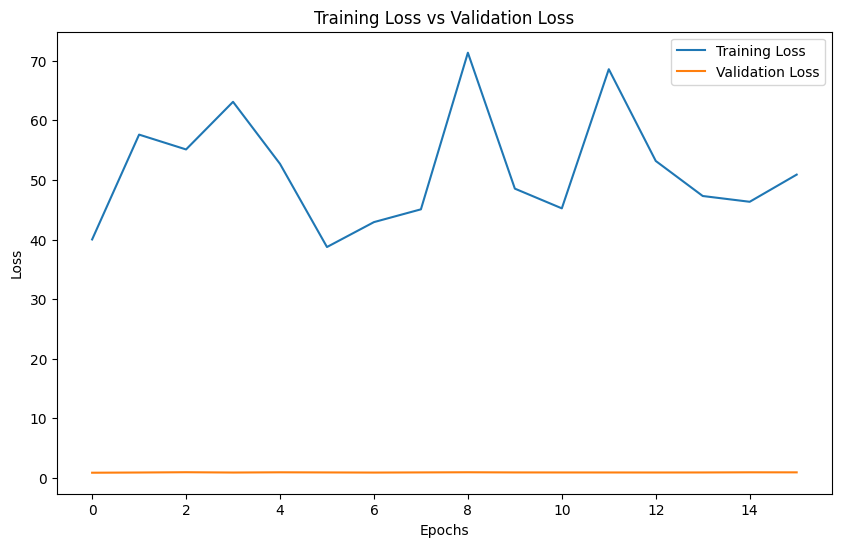

In [ ]:
# Early stopping callback
early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

# Train the VAE
history = vae.fit(
    X_train_scaled,
    epochs=100,
    batch_size=64,
    shuffle=True,
    validation_data=(X_val_scaled,),
    callbacks=[early_stopping]
)

# Plot the training loss vs validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()
plt.show()

# Helper function to encode and decode
def encode_decode(vae, data):
    _, _, z = vae.encode(data)
    return vae.decode(z)



In [ ]:
# Reconstruct data
X_train_reconstructed = encode_decode(vae, X_train_scaled)
train_reconstruction_error = np.mean(np.square(X_train_scaled - X_train_reconstructed), axis=1)

# Calculate reconstruction error for validation data
X_val_reconstructed = encode_decode(vae, X_val_scaled)
val_reconstruction_error = np.mean(np.square(X_val_scaled - X_val_reconstructed), axis=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - loss: 414.3036 - val_loss: 0.0187
Epoch 2/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 45.9293 - val_loss: 0.0215
Epoch 3/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - loss: 27.0574 - val_loss: 0.3906
Epoch 4/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - loss: 137.9678 - val_loss: 0.5487
Epoch 5/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - loss: 66.2447 - val_loss: 0.0755
Epoch 6/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 17.3386 - val_loss: 0.1795
Epoch 7/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - loss: 14.2831 - val_loss: 0.6930
Epoch 8/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 16.3061 - val_loss: 0.0298
Epoch 9/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 84.1836 - val_loss: 0.0573
Epoch 10/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - loss: 1.9960 - val_loss: 1.6514
Epoch 11/100
10745/10745 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - loss: 6

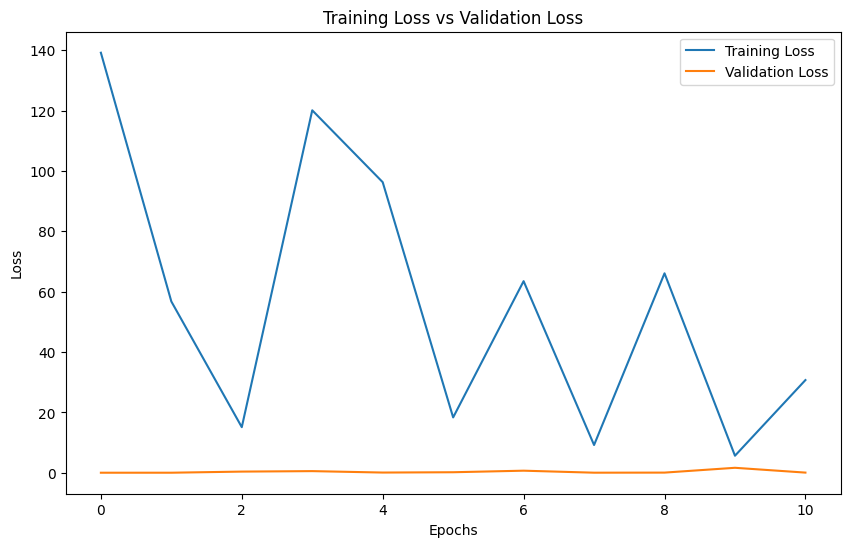

21490/21490 ━━━━━━━━━━━━━━━━━━━━ 31s 1ms/step
5373/5373 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Training Mean: 0.6106528639793396
Validation Mean: 0.6119848489761353
Training RMSE: 11.100805139982386
Validation RMSE: 0.13687741065188708


In [ ]:
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import numpy as np

import matplotlib.pyplot as plt

# Best hyperparameters
best_params = {'n_units1': 23, 'n_units2': 30, 'learning_rate': 0.005596230497244941, 'gamma': 0.2869858485567594}

# # Define the ANN model
# model = Sequential()
# model.add(Dense(best_params['n_units1'], input_dim=X_train_scaled.shape[1], activation='relu'))
# model.add(Dense(best_params['n_units2'], activation='relu'))
# model.add(Dense(1, activation='linear'))

model = Sequential()
model.add(Dense(best_params['n_units1'], input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dense(best_params['n_units2'], activation='relu'))
model.add(Dense(1, activation='linear'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=best_params['learning_rate']), loss='mse')

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train_scaled, train_reconstruction_error,
                    epochs=100,
                    batch_size=64,
                    shuffle=True,
                    validation_data=(X_val_scaled, val_reconstruction_error),
                    callbacks=[early_stopping])

# Plot the training loss vs validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()
plt.show()

# Calculate mean and RMSE for training and validation data
train_predictions = model.predict(X_train_scaled)
val_predictions = model.predict(X_val_scaled)

train_mean = np.mean(train_predictions)
val_mean = np.mean(val_predictions)

train_rmse = np.sqrt(mean_squared_error(train_reconstruction_error, train_predictions))
val_rmse = np.sqrt(mean_squared_error(val_reconstruction_error, val_predictions))

print(f'Training Mean: {train_mean}')
print(f'Validation Mean: {val_mean}')
print(f'Training RMSE: {train_rmse}')
print(f'Validation RMSE: {val_rmse}')

In [ ]:
import numpy as np


# 1. Input X_test_scaled into the trained AE to obtain RE
X_test_reconstructed = autoencoder.predict(X_test_scaled)
reconstruction_error = np.mean(np.square(X_test_scaled - X_test_reconstructed), axis=1)


# 2. Feed X_test_scaled into the trained NN to predict expected RE (epsilon)
epsilon = model.predict(X_test_scaled)

# 3. Compare actual RE with expected RE + sensitivity parameter (gamma)
gamma = 0 #0.28
anomalies = reconstruction_error > (epsilon.flatten() + gamma)

# 'anomalies' is a boolean array where True indicates an anomaly.
# You can now use this array to identify anomalies in your X_test data.
# For example, to get the indices of the anomalies:
anomaly_indices = np.where(anomalies)[0]

anomaly_indices

1581/1581 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


array([    0,     1,     2, ..., 50574, 50579, 50580])

In [ ]:
df_test['vae_anomaly'] = anomalies.astype(int)

In [ ]:

# Evaluate the model's performance
true_anomalies = df_test['status_type_id'] == 4
predicted_anomalies = df_test['ae_anomaly'] == 1

precision = precision_score(true_anomalies, predicted_anomalies)
recall = recall_score(true_anomalies, predicted_anomalies)
f1 = f1_score(true_anomalies, predicted_anomalies)
accuracy = accuracy_score(true_anomalies, predicted_anomalies)


print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'Accuracy: {accuracy}')

Precision: 0.03986259214198812
Recall: 0.4079091907726108
F1 Score: 0.07262770153535222
Accuracy: 0.4376445472335883


In [ ]:
vae_anomaly_counts = df_test.groupby(['vae_anomaly','status_type_id']).size()

vae_anomaly_counts

vae_anomaly  status_type_id
0            0                 23324
             3                  1703
             4                  1957
             5                  3268
1            0                 15770
             3                  1517
             4                   774
             5                  2276
dtype: int64

In [ ]:
vae.summary()

Model: "vae_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gaussian_noise_6 (GaussianNoise)     │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 44)                  │           3,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 25)                  │           1,125 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 4)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 4)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sampling_1 (Sampling)                │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 25)                  │             125 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 44)                  │           1,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 81)                  │           3,645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,567 (115.50 KB)

 Trainable params: 9,855 (38.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,712 (77.00 KB)

## CARE SCORE

In [29]:
from typing import List, Dict

from care_score import CAREScore, Coverage, Accuracy, Reliability, Earliness

In [38]:
def care_score_processor(df_test, anomaly_column):
  new_df = df_test.copy()

  # Rename 'status_type_id' to 'status_id'
  new_df.rename(columns={'status_type_id': 'status_id'}, inplace=True)

  # Rename anomaly column to 'anomaly'
  new_df.rename(columns={anomaly_column: 'anomaly'}, inplace=True)

  # Process the 'anomaly' column: -1 to 0, 0 to 0, 1 to 1 (in integer form)
  new_df['anomaly'] = new_df['anomaly'].apply(lambda x: 0 if x == -1 else (1 if x == 1 else x))

  # Process the 'status_id' column: 0, 2 to 0, rest to 1
  new_df['status_id'] = new_df['status_id'].apply(lambda x: 'normal' if x in [0, 2] else 'not normal')

  return new_df


In [39]:
df_ae_care_score = care_score_processor(df_test, 'ae_anomaly')

df_ae_care_score.groupby(['anomaly', 'status_id']).size()



anomaly  status_id 
0        normal        16572
         not normal     6071
1        normal        22522
         not normal     5424
dtype: int64

In [41]:
anomaly_results = pd.DataFrame({
    'anomaly': df_ae_care_score['anomaly']
}, index=df_ae_care_score.index)

In [49]:
care_calculator = CAREScore(omega1=1.0, omega2=1.0, omega3=1.0, omega4=2.0)

# Calculate CARE score and its components
scores = care_calculator.calculate_care_score(df_ae_care_score, anomaly_results)

# Print the results
print(f"Score CARE: {scores['care']:.4f}")
print(f"  Coverage: {scores['coverage']:.4f}")
print(f"  Accuracy: {scores['accuracy']:.4f}")
print(f"  Reliability: {scores['reliability']:.4f}")
print(f"  Earliness: {scores['earliness']:.4f}")


ValueError: operands could not be broadcast together with shapes (54061,) (1726,) 

In [48]:
# prompt: check the shape of df_ae_care_score and anomaly results

print("Shape of df_ae_care_score:", df_ae_care_score.shape)
print("Shape of anomaly_results:", anomaly_results.shape)


Shape of df_ae_care_score: (50589, 90)
Shape of anomaly_results: (50589, 1)


In [47]:
anomaly_results.anomaly.unique()

array([1, 0])